In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras import callbacks
from tensorflow.keras import layers, Sequential, callbacks
from tensorflow.keras.layers import Conv2D, Flatten, Dense, LSTM, Dropout, GRU, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers.schedules import ExponentialDecay
for dirnam, _, filenames in os.walk('/traffic.csv'):
  for filename in filenames:
    print(os.path.join(dirname, filename))


In [2]:
data = pd.read_csv("traffic.csv")
data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
data['DateTime']=pd.to_datetime(data['DateTime'])

data["Year"]=data['DateTime'].dt.year

data["Month"]=data['DateTime'].dt.month

data["Date_no"]=data['DateTime'].dt.day

data["Hour"]=data['DateTime'].dt.hour

data["Day"]= data['DateTime'].dt.strftime("%A")

<Axes: xlabel='Date_no', ylabel='Vehicles'>

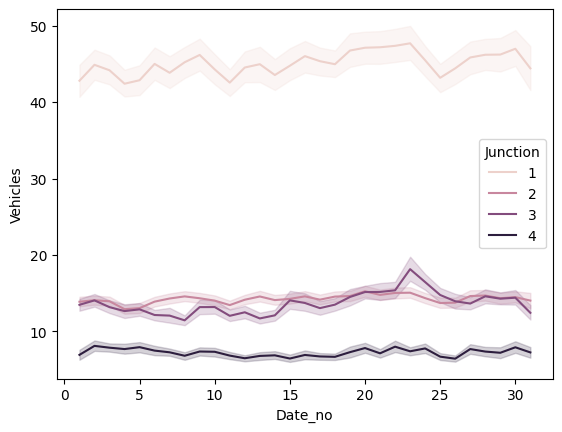

In [4]:
sns.lineplot(x=data['Date_no'], y="Vehicles", data=data, hue='Junction')


In [5]:
data = data[(data['Junction'] == 1)]
def Normalize(df,col):
  average = df[col].mean()
  stdev = df[col].std()
  df_normalized = (df[col] - average) / stdev
  df_normalized = df_normalized.to_frame()
  return df_normalized, average, stdev

def Difference(df, col, interval):
  diff = []
  for i in range(interval):
    diff.append(None)

  for i in range(interval, len(df)):
    value = df[col][i] - df[col][i - interval]
    diff.append(value)
  return diff

In [6]:
df_N, av, std = Normalize(data, "Vehicles")
Diff = Difference(df_N, col="Vehicles", interval=(24*7)) #taking a week's diffrence
df_N.columns = ["Norm"]
df_N["Diff"]= Diff
df_N = df_N[24*7:]
df = df_N["Diff"].dropna()
df = df.to_frame()
df.head()

,Diff
168,-0.086925
169,0.130387
170,0.043462
171,0.043462
172,0.043462


In [7]:
df.shape

(14424, 1)

In [10]:
def Split_data(df):
  training_size = int(len(df)*0.80)
  data_len = len(df)
  train, test = df[0:training_size], df[training_size:data_len]
  train, test = train.values.reshape(-1,1), test.values.reshape(-1,1)
  return train, test

df_train, df_test = Split_data(df)

In [24]:
def TnF(df):
 end_len = len(df)
 X = []
 Y = []
 steps = 32
 for i in range(steps, end_len):
  X.append(df[i - steps:i, 0])
  Y.append(df[i, 0])
 X, Y = np.array(X), np.array(Y)
 return X ,Y

def FeatureFixShape(train, test):
  train = np.reshape(train, (train.shape[0], train.shape[1], 1))
  test = np.reshape(test, (test.shape[0], test.shape[1],1))
  return train, test

X_train, y_train = TnF(df_train)
X_test, y_test = TnF(df_test)
X_train, X_test = FeatureFixShape(X_train, X_test)



In [43]:
X_train, X_test = FeatureFixShape(X_train, X_test)
from sklearn.metrics import mean_absolute_error
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=10000,
    decay_rate=0.9
)
def MLP_model(X_Train, y_Train, X_Test, y_Test):
  X_Train = np.squeeze(X_Train)
  X_Test = np.squeeze(X_Test)
  early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
  model = Sequential()
  model.add(Dense(100, activation='relu', input_dim=X_train.shape[1]))
  model.add(Dropout(0.2))
  model.add(Dense(20, activation='relu', input_dim=X_Train.shape[1]))
  model.add(Dropout(0.2))
  model.add(Dense(1))
  model.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9),loss='mean_squared_error')
  model.fit(X_Train, y_Train, validation_data=(X_test, y_test), epochs=50, batch_size=120, callbacks=[early_stopping])
  pred_MLP = model.predict(X_Test)
  return pred_MLP

In [44]:
def RMSE_value(test,predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("the root mean squared error is{}.".format(rmse))
  return rmse


def MAE_Value(test,predicted):
  mae = mean_absolutr_error(test, predicted)
  print("the MAE is {}.".format(mae))
  return mae


def PredictionsPlote(test, predicted, m):
  plt.figure(figsize=(12,5))
  plt.polt(test, color=colors[m],label="True Value", alpha=0.5)
  plt.plot(predicted,label="Predicted Values")
  plt.titel("Traffic Prediction Vs True Values")
  plt.xlabel("DateTime")
  plt.ylabel("Number of Vehicles")
  plt.legend()
  plt.show

In [45]:
pred_MLP = MLP_model(X_train, y_train, X_test, y_test)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0759 - val_loss: 0.0693
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0581 - val_loss: 0.0633
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0548 - val_loss: 0.0609
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0520 - val_loss: 0.0596
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0509 - val_loss: 0.0591
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0496 - val_loss: 0.0576
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0493 - val_loss: 0.0575
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0485 - val_loss: 0.0578
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0480 - val_loss: 0.0570
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0477 - val_loss: 0.0566
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0482 - val_loss: 0.0574
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0473 - val_loss: 0.0560
